# RenAIssance OCR — Notebook 2: Core OCR Model

In [1]:
# ── Install dependencies ────────────────────────────────────────────────────
!pip install -q transformers==4.40.0 datasets accelerate jiwer editdistance albumentations
print('Dependencies installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 73.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 77.5 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
Dependencies installed


In [2]:
import os, re, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
)
import jiwer
import editdistance

print('All imports successful')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

All imports successful
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda


In [3]:
# ── Path & hyper-parameter constants ──────────────────────────────────────
DATASET_DIR = '/kaggle/input/datasets/arnavtripathi01/renaissance-dataset'
CROPPED_DIR = f'{DATASET_DIR}/cropped_images'
LABELS_DIR  = f'{DATASET_DIR}/processed_labels'
CSV_PATH    = f'{DATASET_DIR}/dataset.csv'
OUTPUT_DIR  = '/kaggle/working/ocr_outputs'
MODEL_DIR   = '/kaggle/working/trocr_renaissance'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

# Model & training
MODEL_NAME       = 'microsoft/trocr-base-printed'
BATCH_SIZE       = 8          # Reduce to 4 if OOM on smaller GPU
EPOCHS           = 3
LR               = 5e-5
MAX_TARGET_LEN   = 128
TARGET_H         = 64         # TrOCR expected input height
TARGET_W         = 384        # Max width; images are padded to this
NUM_BEAMS        = 4          # Beam search width at inference

# Rare character set - diacritics & archaic letterforms specific to 17th-c Spanish
RARE_CHARS = set('áéíóúüñÁÉÍÓÚÜÑçÇãõẽ\u0303')
RARE_BOOST = 4.0              # Max weight multiplier for rare-char-heavy samples
SATURATION = 4                # #rare chars in a sample to reach max weight

print(f'Rare character set: {"".join(sorted(RARE_CHARS))}')
print('Constants configured')

Rare character set: ÁÇÉÍÑÓÚÜáãçéíñóõúü̃ẽ
Constants configured


---
## 1. Dataset Loading & Exploration

In [4]:
# ── Load dataset.csv produced by Notebook 1 ───────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f'Raw dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
display(df.head(3))

# ─── Normalise column names ────────────────────────────────────────────────
col_map = {}
for c in df.columns:
    lc = c.lower()
    if any(k in lc for k in ['image', 'path', 'file']):
        col_map[c] = 'image_path'
    elif any(k in lc for k in ['text', 'label', 'transcript', 'ground']):
        col_map[c] = 'text'
df = df.rename(columns=col_map)

# ─── Resolve absolute image paths ─────────────────────────────────────────
def resolve_path(p):
    p = str(p)
    if os.path.exists(p):
        return p
    candidate = os.path.join(CROPPED_DIR, os.path.basename(p))
    if os.path.exists(candidate):
        return candidate
    return p  # will be filtered below

df['image_path'] = df['image_path'].apply(resolve_path)
df['exists']     = df['image_path'].apply(os.path.exists)

# ─── Clean & filter ────────────────────────────────────────────────────────
df = df[df['exists']].drop(columns=['exists'])
df = df.dropna(subset=['text'])
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() > 3].reset_index(drop=True)

# Source identifier (used for stratified split + per-source evaluation)
df['source'] = df['image_path'].apply(
    lambda p: Path(p).stem.split('_page_')[0] if '_page_' in str(p) else Path(p).stem[:20]
)

print(f'\nClean dataset: {len(df)} samples across {df["source"].nunique()} sources')
print('Source distribution:')
print(df['source'].value_counts().to_string())

Raw dataset shape: (22, 2)
Columns: ['image', 'text']


,image,text
0,/kaggle/working/images/porcones2351628_page_1.jpg,"POR\nDOÑA CATALINA DE \nLaçarraga y Zarate, vi..."
1,/kaggle/working/images/porcones2351628_page_2.jpg,"- left\nca de Caycedo su hija, donzella noble ..."
2,/kaggle/working/images/porcones228381646_page_...,"ticia de esta parte en ajuitar con certeza, y ..."



Clean dataset: 22 samples across 6 sources
Source distribution:
source
porcones228381646          5
porcones2351628            4
porcones74861650           4
buendiainstruccion         3
covarrubiastesorolengua    3
guardiolatratadonobleza    3


Total characters in corpus : 36,667
Unique characters          : 81
Rare / diacritic chars     : {'Ñ': 2, 'ç': 6, 'ñ': 87, 'é': 21, 'ó': 36, 'á': 15, 'í': 26}


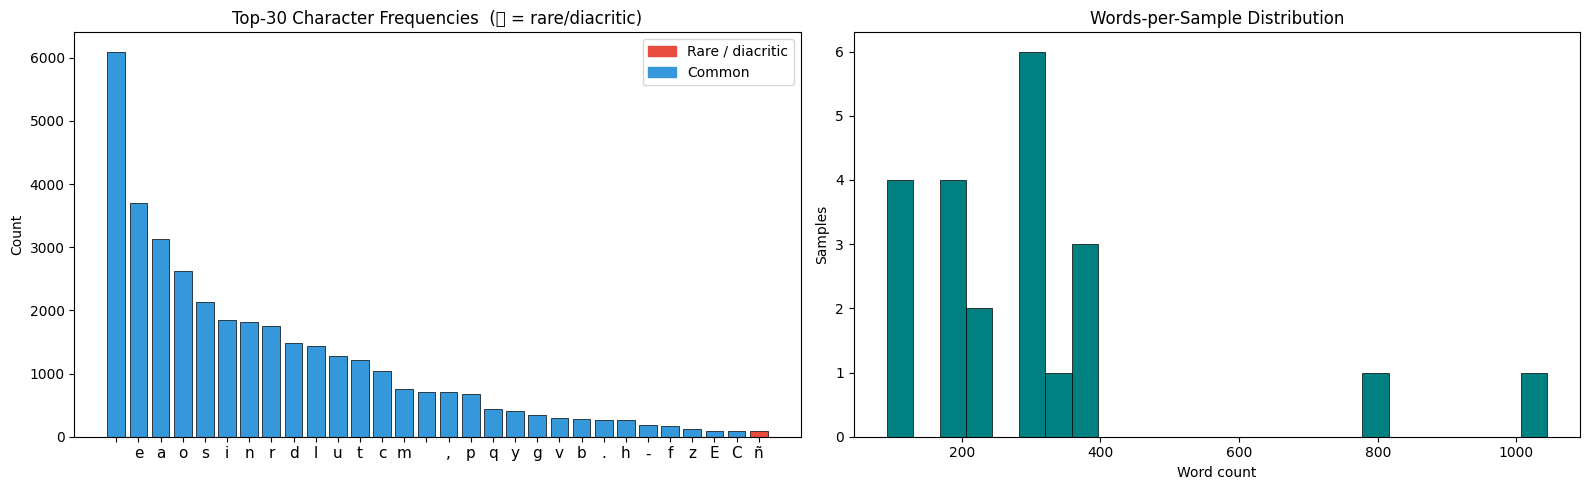

Mean words/sample: 304.0  |  Max: 1044


In [5]:
# ── Corpus-level character statistics ─────────────────────────────────────
all_text  = ' '.join(df['text'].tolist())
char_freq = Counter(all_text)
rare_freq = {c: n for c, n in char_freq.items() if c in RARE_CHARS}

print(f'Total characters in corpus : {len(all_text):,}')
print(f'Unique characters          : {len(char_freq)}')
print(f'Rare / diacritic chars     : {rare_freq}')

top30 = char_freq.most_common(30)
chars, freqs = zip(*top30)
colors = ['#e74c3c' if c in RARE_CHARS else '#3498db' for c in chars]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(len(chars)), freqs, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(chars)))
axes[0].set_xticklabels(list(chars), fontsize=11)
axes[0].set_title('Top-30 Character Frequencies  (🔴 = rare/diacritic)', fontsize=12)
axes[0].set_ylabel('Count')
handles = [mpatches.Patch(color='#e74c3c', label='Rare / diacritic'),
           mpatches.Patch(color='#3498db', label='Common')]
axes[0].legend(handles=handles)

wlens = [len(t.split()) for t in df['text']]
axes[1].hist(wlens, bins=25, color='teal', edgecolor='black', linewidth=0.5)
axes[1].set_title('Words-per-Sample Distribution', fontsize=12)
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Samples')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/dataset_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean words/sample: {np.mean(wlens):.1f}  |  Max: {max(wlens)}')

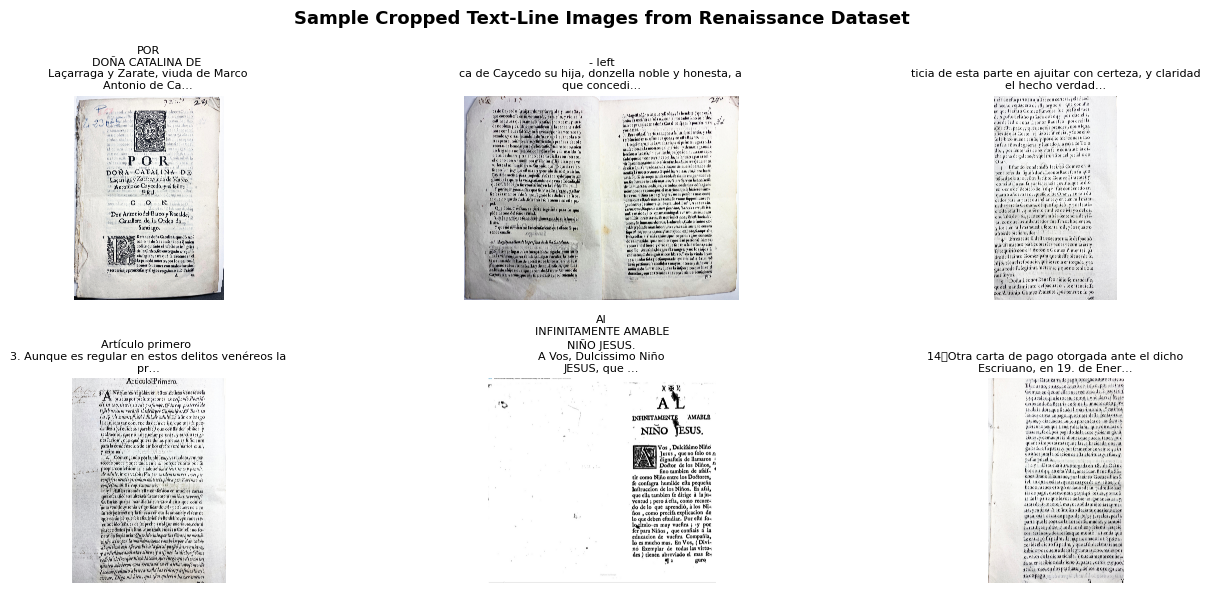

In [6]:
# ── Visual check: show sample cropped text-line images ─────────────────────
n = min(6, len(df))
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= n:
        ax.axis('off'); continue
    try:
        img = Image.open(df['image_path'].iloc[i]).convert('RGB')
        ax.imshow(img)
        label = df['text'].iloc[i]
        label = (label[:70] + '…') if len(label) > 70 else label
        ax.set_title(label, fontsize=8, wrap=True)
    except Exception as e:
        ax.set_title(f'Load error: {e}', fontsize=7)
    ax.axis('off')

plt.suptitle('Sample Cropped Text-Line Images from Renaissance Dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Weighted Learning for Rare Renaissance Characters

17th-century Spanish printed text contains characters that are:
- **Rare in training data**: diacritics (á, é, ñ, ü), the cedilla (ç), archaic tildes
- **Visually ambiguous**: the long-s (ſ) looks like 'f'; 'u' and 'v' were interchangeable

**Strategy**: `WeightedRandomSampler` boosts samples with more rare characters.

$$w_i = 1 + (\text{RARE\_BOOST} - 1) \cdot \min\left(\frac{n_{\text{rare}}^{(i)}}{\text{SATURATION}}, 1\right)$$

where $n_{\text{rare}}^{(i)}$ is the count of rare characters in sample $i$. This caps at `RARE_BOOST = 4.0×` for samples with ≥ 4 rare characters.

Sample weight statistics
  min    = 1.00
  max    = 4.00
  mean   = 3.52
  Samples with boosted weight (w>1): 21 / 22


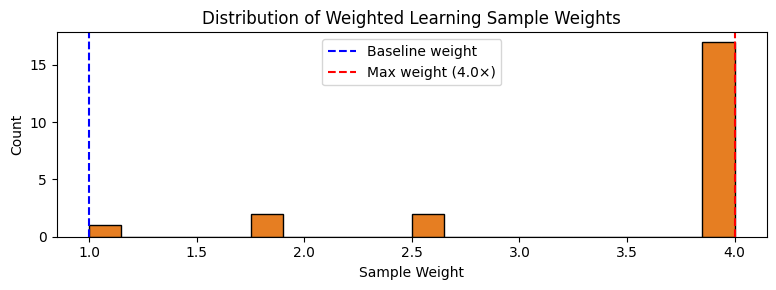

In [7]:
def compute_sample_weights(texts, rare_chars=RARE_CHARS,
                           rare_boost=RARE_BOOST, saturation=SATURATION):
    """Per-sample weights based on rare-character count."""
    weights = []
    for text in texts:
        rare_count = sum(1 for c in text if c in rare_chars)
        w = 1.0 + (rare_boost - 1.0) * min(rare_count / saturation, 1.0)
        weights.append(w)
    return np.array(weights, dtype=np.float32)

all_weights = compute_sample_weights(df['text'].tolist())
print('Sample weight statistics')
print(f'  min    = {all_weights.min():.2f}')
print(f'  max    = {all_weights.max():.2f}')
print(f'  mean   = {all_weights.mean():.2f}')
print(f'  Samples with boosted weight (w>1): {(all_weights > 1.0).sum()} / {len(all_weights)}')

# Distribution of weights
plt.figure(figsize=(8, 3))
plt.hist(all_weights, bins=20, color='#e67e22', edgecolor='black')
plt.axvline(1.0, color='blue',  ls='--', label='Baseline weight')
plt.axvline(RARE_BOOST, color='red', ls='--', label=f'Max weight ({RARE_BOOST}×)')
plt.xlabel('Sample Weight'); plt.ylabel('Count')
plt.title('Distribution of Weighted Learning Sample Weights', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_weights.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Data Augmentation

In [8]:
def get_augmentation(is_train: bool):
    """Augmentation pipeline for printed historical text images."""
    if not is_train:
        return None 
    return A.Compose([
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=1.0),
            A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=15, val_shift_limit=20, p=1.0),
        ], p=0.5),
        A.OneOf([
            A.GaussNoise(var_limit=(5.0, 25.0), p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        ], p=0.3),
        A.ShiftScaleRotate(
            shift_limit=0.02, scale_limit=0.05,
            rotate_limit=2, border_mode=0, value=(255, 255, 255), p=0.4
        ),
    ])

print('Augmentation pipeline defined')

Augmentation pipeline defined


---
## 4. Dataset Class

In [9]:
class RenaissanceOCRDataset(Dataset):
    """PyTorch Dataset for TrOCR fine-tuning on Renaissance Spanish printed text."""

    def __init__(self, df, processor, is_train=True, max_target_length=MAX_TARGET_LEN):
        self.df               = df.reset_index(drop=True)
        self.processor        = processor
        self.is_train         = is_train
        self.max_target_length = max_target_length
        self.aug              = get_augmentation(is_train)

    def __len__(self):
        return len(self.df)

    def _load_image(self, path: str) -> Image.Image:
        """Load, convert to RGB, resize to TARGET_H, pad to TARGET_W."""
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (TARGET_W, TARGET_H), (255, 255, 255))
            return img

        w, h = img.size
        # Resize preserving aspect ratio to target height
        new_w = max(1, int(w * TARGET_H / h))
        img = img.resize((new_w, TARGET_H), Image.LANCZOS)

        # Pad right with white to TARGET_W (or crop if very wide)
        if new_w < TARGET_W:
            padded = Image.new('RGB', (TARGET_W, TARGET_H), (255, 255, 255))
            padded.paste(img, (0, 0))
            return padded
        elif new_w > TARGET_W:
            return img.crop((0, 0, TARGET_W, TARGET_H))
        return img

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        text = str(row['text'])
        img  = self._load_image(row['image_path'])

        # Apply augmentation on numpy array, then reconstruct PIL
        if self.aug is not None:
            img_np  = np.array(img, dtype=np.uint8)
            img_np  = self.aug(image=img_np)['image']
            img     = Image.fromarray(img_np)

        # TrOCR processor handles final preprocessing (resize / normalise)
        pixel_values = self.processor(images=img, return_tensors='pt').pixel_values

        # Tokenise target text
        with self.processor.tokenizer.as_target_tokenizer():
            labels = self.processor.tokenizer(
                text,
                padding='max_length',
                max_length=self.max_target_length,
                truncation=True,
            ).input_ids

        # Mask padding in loss
        pad_id = self.processor.tokenizer.pad_token_id
        labels = [lbl if lbl != pad_id else -100 for lbl in labels]

        return {
            'pixel_values': pixel_values.squeeze(0),
            'labels': torch.tensor(labels, dtype=torch.long),
        }

print('RenaissanceOCRDataset class defined')

RenaissanceOCRDataset class defined


---
## 5. Train / Validation Split

In [10]:
from sklearn.model_selection import train_test_split

# Stratify by source to ensure each document is represented in both splits
n_classes  = df['source'].nunique()
n_test_abs = max(1, int(len(df) * 0.2))

if n_classes > 1 and n_test_abs >= n_classes:
    stratify_col = df['source'].values      
    print(f'Using stratified split ({n_classes} sources, {n_test_abs} test samples)')
else:
    stratify_col = None                   
    print(f'Falling back to random split '
          f'(test_size={n_test_abs} < n_classes={n_classes})')

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=stratify_col
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'Train samples : {len(train_df)}')
print(f'Val   samples : {len(val_df)}')
print(f'Train sources : {train_df["source"].value_counts().to_dict()}')

Falling back to random split (test_size=4 < n_classes=6)
Train samples : 17
Val   samples : 5
Train sources : {'porcones228381646': 5, 'buendiainstruccion': 3, 'porcones74861650': 3, 'guardiolatratadonobleza': 2, 'porcones2351628': 2, 'covarrubiastesorolengua': 2}


---
## 6. Load TrOCR Model & Configure for Fine-tuning

In [11]:
print(f'Loading TrOCR: {MODEL_NAME}')
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model     = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

# ── Critical token config ─────────────────────────────────────────────────
model.config.decoder_start_token_id = processor.tokenizer.bos_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size
model.generation_config.eos_token_id   = processor.tokenizer.eos_token_id
model.generation_config.max_new_tokens = MAX_TARGET_LEN

model = model.to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters()) / 1e6
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f'Total parameters    : {total_params:.1f}M')
print(f'Trainable parameters: {trainable_params:.1f}M')
print('Model loaded')

Loading TrOCR: microsoft/trocr-base-printed


2026-03-31 15:02:37.502822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774969357.881645      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774969357.987297      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774969358.946416      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774969358.946449      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774969358.946452      55 computation_placer.cc:177] computation placer alr

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Total parameters    : 333.9M
Trainable parameters: 333.9M
Model loaded


---
## 7. DataLoaders with Weighted Sampler

In [12]:
train_dataset = RenaissanceOCRDataset(train_df, processor, is_train=True)
val_dataset   = RenaissanceOCRDataset(val_df,   processor, is_train=False)

# WeightedRandomSampler: upsample rare-character samples during training
train_weights = compute_sample_weights(train_df['text'].tolist())
sampler = WeightedRandomSampler(
    weights=torch.tensor(train_weights, dtype=torch.float),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

# Sanity-check one batch
batch = next(iter(train_loader))
print(f'Batch pixel_values shape : {batch["pixel_values"].shape}')
print(f'Batch labels       shape : {batch["labels"].shape}')

Train batches : 3
Val   batches : 1
Batch pixel_values shape : torch.Size([8, 3, 384, 384])
Batch labels       shape : torch.Size([8, 128])


---
## 8. Evaluation Metric Helpers

In [13]:
def compute_cer(predictions, references):
    """Character Error Rate via jiwer (treats chars as words)."""
    preds_c = [' '.join(list(str(p))) for p in predictions]
    refs_c  = [' '.join(list(str(r))) for r in references]
    return jiwer.wer(refs_c, preds_c)

def compute_wer(predictions, references):
    """Word Error Rate."""
    return jiwer.wer([str(r) for r in references],
                     [str(p) for p in predictions])

def evaluate_loader(model, loader, processor, device, max_batches=None):
    """Run model on a dataloader and return CER, WER, predictions, references."""
    model.eval()
    all_preds, all_refs = [], []
    pad_id = processor.tokenizer.pad_token_id

    with torch.no_grad():
        for i, batch in enumerate(tqdm(loader, desc='Evaluating', leave=False)):
            if max_batches and i >= max_batches:
                break
            pv = batch['pixel_values'].to(device)
            lb = batch['labels']

            gen_ids  = model.generate(pv, num_beams=NUM_BEAMS, max_new_tokens=MAX_TARGET_LEN)
            pred_str = processor.batch_decode(gen_ids, skip_special_tokens=True)

            lab_ids = lb.clone()
            lab_ids[lab_ids == -100] = pad_id
            ref_str  = processor.batch_decode(lab_ids, skip_special_tokens=True)

            all_preds.extend(pred_str)
            all_refs.extend(ref_str)

    cer = compute_cer(all_preds, all_refs)
    wer = compute_wer(all_preds, all_refs)
    return cer, wer, all_preds, all_refs

print('Metric helpers defined')

Metric helpers defined


---
## 9. Fine-tuning Loop

In [14]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.15,
    anneal_strategy='cos',
)

history   = {'epoch': [], 'train_loss': [], 'val_cer': [], 'val_wer': [], 'lr': []}
best_cer  = float('inf')
best_epoch = 0

print('=' * 62)
print(f'TrOCR Fine-tuning  |  Epochs={EPOCHS}  LR={LR}  Batch={BATCH_SIZE}')
print('=' * 62)

for epoch in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0

    for batch in tqdm(train_loader, desc=f'Ep {epoch:02d}/{EPOCHS} [train]', leave=False):
        pv = batch['pixel_values'].to(DEVICE)
        lb = batch['labels'].to(DEVICE)

        out  = model(pixel_values=pv, labels=lb)
        loss = out.loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    # ── Validation ────────────────────────────────────────────────────────
    val_cer, val_wer, _, _ = evaluate_loader(model, val_loader, processor, DEVICE)

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)
    history['val_cer'].append(val_cer)
    history['val_wer'].append(val_wer)
    history['lr'].append(scheduler.get_last_lr()[0])

    save_flag = ''
    if val_cer < best_cer:
        best_cer   = val_cer
        best_epoch = epoch
        model.save_pretrained(MODEL_DIR)
        processor.save_pretrained(MODEL_DIR)
        save_flag = '  ← best saved'

    print(f'Epoch {epoch:02d} | loss={avg_loss:.4f}  CER={val_cer:.4f}  WER={val_wer:.4f}{save_flag}')

print(f'\nTraining complete. Best CER={best_cer:.4f} at epoch {best_epoch}')

TrOCR Fine-tuning  |  Epochs=3  LR=5e-05  Batch=8


Ep 01/3 [train]:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 291, in _feed
    queue_sem.release()
ValueError: semaphore or lock released too many times


Epoch 01 | loss=10.0853  CER=0.8143  WER=1.1293  ← best saved


...

Epoch 02 | loss=8.9430  CER=0.9896  WER=1.0000


Ep 03/3 [train]:   0%|          | 0/3 [00:00<?, ?it/s]

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 291, in _feed
    queue_sem.release()
ValueError: semaphore or lock released too many times


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 03 | loss=8.1867  CER=0.9926  WER=1.0000

Training complete. Best CER=0.8143 at epoch 1


Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 291, in _feed
    queue_sem.release()
ValueError: semaphore or lock released too many times


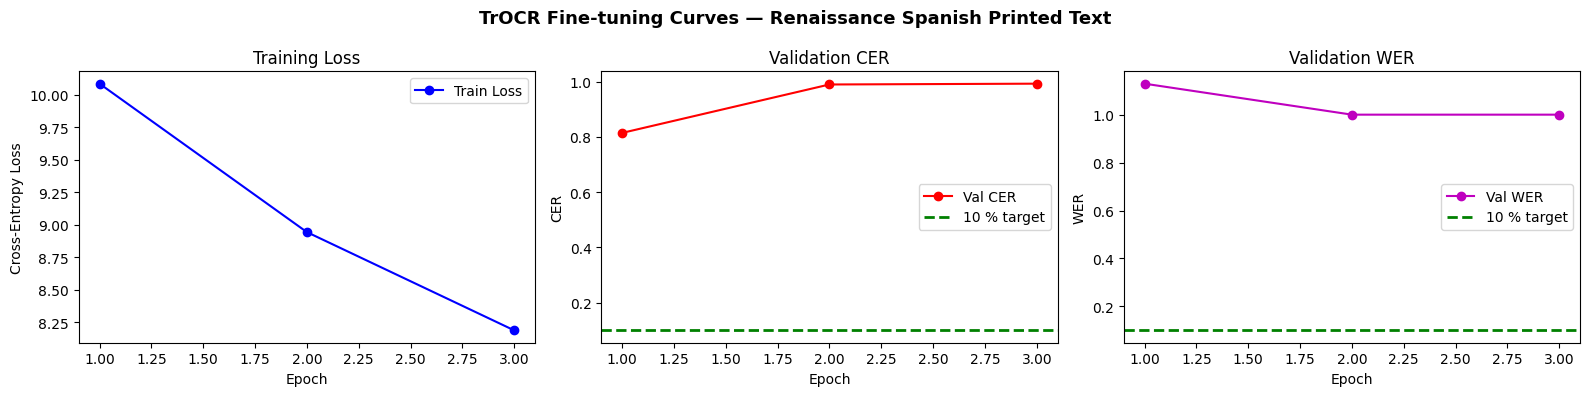

In [15]:
# ── Training curves ────────────────────────────────────────────────────────
hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist.epoch, hist.train_loss, 'b-o', label='Train Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss', fontsize=12); axes[0].legend()

axes[1].plot(hist.epoch, hist.val_cer, 'r-o', label='Val CER')
axes[1].axhline(0.10, ls='--', color='green', lw=2, label='10 % target')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('CER')
axes[1].set_title('Validation CER', fontsize=12); axes[1].legend()

axes[2].plot(hist.epoch, hist.val_wer, 'm-o', label='Val WER')
axes[2].axhline(0.10, ls='--', color='green', lw=2, label='10 % target')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('WER')
axes[2].set_title('Validation WER', fontsize=12); axes[2].legend()

plt.suptitle('TrOCR Fine-tuning Curves — Renaissance Spanish Printed Text',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Renaissance Spanish Lexicon & Constrained Decoder

In [16]:
# ── Curated archaic/abbreviation wordlist ─────────────────────────────────
ARCHAIC_WORDS = {
    'vn','vna','vno','vnos','vnas',        # un/una…
    'q','qe','qien','qal','ql',            # que/quien/cual…
    'delos','delas','delo','dela',
    'enla','enlos','enlas','enlo',
    'deste','desta','desto','destos','destas',
    'dello','della','dellos','dellas',
    'aquel','aquella','aquello','aqueste','aquesta',
    'porq','pq','paraq',
    'dho','dha','dhos','dhas',             # dicho/dicha…
    'xpo','xpistianos','xptianos',         # Cristo/Christianos
    'vm','vmd','vms','vra','vras','vro','vros',  # vuestra merced…
    'sr','sra','sres','sor',
    'fho','fha',                           # fecho/fecha (archaic)
    'agora','aora',                        # ahora
    'hazer','haçer','haziendo','hazie',
    'dezir','deçir','dize','dixo','dixeron',
    'traer','traher','traxo',
    'mesmo','mesma','mesmos','mesmas',
    'ansí','assí','anssi',
    'nobleza','noblesa','noblesas',
    'hidalgo','hidalguía','hidalga',
    'linaje','linages','linaxe',
    'merced','mercedes','ilustre','ilustrísimo',
    'don','doña','dona','excelencia',
    'españa','reino','reinos','rey','reyes',
    'cédula','cédulas','privilegio','privilegios',
    'natural','naturales','naturaleza',
}

def build_lexicon(df, extra_words=ARCHAIC_WORDS):
    """Build Renaissance Spanish lexicon from ground truth + archaic wordlist."""
    lexicon = set()
    pattern = re.compile(r"[\wáéíóúüñÁÉÍÓÚÜÑçÇ']+")
    for text in df['text']:
        lexicon.update(w.lower() for w in pattern.findall(str(text)))
    lexicon.update(w.lower() for w in extra_words)
    return lexicon

lexicon = build_lexicon(df)
print(f'Lexicon size: {len(lexicon):,} unique word forms')

# Save for Notebook 3
with open(f'{OUTPUT_DIR}/renaissance_lexicon.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(sorted(lexicon)))
print('Lexicon saved')

Lexicon size: 2,173 unique word forms
Lexicon saved


In [17]:
class RenaissanceLexiconDecoder:
    """Constrained word-level decoder using edit-distance lookup in a
        Renaissance Spanish lexicon."""

    # Historical OCR confusions for 17th-century Spanish print
    _CONFUSION = str.maketrans('fujFUJ', 'suvSUV')
    _STRIP = str.maketrans('', '', '.,:;!?¡¿\"()[]')

    def __init__(self, lexicon, max_edit_dist=2, min_word_len=3):
        self.lex_set = set(lexicon)
        self.lex_list = list(lexicon)
        self.max_dist = max_edit_dist
        self.min_len  = min_word_len
        self._cache   = {}

    def _normalise(self, word):
        return word.lower().translate(self._STRIP)

    def _dist(self, a, b):
        """Min edit distance with and without confusion mapping."""
        d1 = editdistance.eval(a, b)
        if d1 == 0:
            return 0
        d2 = editdistance.eval(a.translate(self._CONFUSION), b)
        return min(d1, d2)

    def correct_word(self, word):
        norm = self._normalise(word)
        if norm in self._cache:
            return self._cache[norm]

        # Keep short tokens, digits, already-valid words unchanged
        if len(norm) < self.min_len or norm.isnumeric() or norm in self.lex_set:
            self._cache[norm] = word
            return word

        best, best_d = word, self.max_dist + 1
        for lw in self.lex_list:
            if abs(len(lw) - len(norm)) > self.max_dist:
                continue
            d = self._dist(norm, lw)
            if d < best_d:
                best_d, best = d, lw
                if d == 0:
                    break

        result = best if best_d <= self.max_dist else word
        self._cache[norm] = result
        return result

    def decode(self, text):
        """Apply lexicon correction token-by-token."""
        return ' '.join(self.correct_word(tok) for tok in text.split())


lex_decoder = RenaissanceLexiconDecoder(lexicon, max_edit_dist=2)

# Demonstration
demos = [
    'La noblefa de efpaña es muy antigua',
    'el Rei don Phelipe por la gracia de Dios',
    'feruicio de fu Mageftad y bien publico',
]
print('Lexicon decoder demonstration:')
for d in demos:
    print(f'  IN : {d}')
    print(f'  OUT: {lex_decoder.decode(d)}')
    print()

Lexicon decoder demonstration:
  IN : La noblefa de efpaña es muy antigua
  OUT: La noblesa de españa es muy antiguos

  IN : el Rei don Phelipe por la gracia de Dios
  OUT: el reo don felipe por La gracia de Dios

  IN : feruicio de fu Mageftad y bien publico
  OUT: servicio de fu magestad y bien publica



---
## 11. Full-dataset Inference

In [18]:
# ── Load best checkpoint ───────────────────────────────────────────────────
print('Loading best model checkpoint …')
best_model     = VisionEncoderDecoderModel.from_pretrained(MODEL_DIR).to(DEVICE)
best_processor = TrOCRProcessor.from_pretrained(MODEL_DIR)
best_model.eval()
print('Checkpoint loaded')

full_dataset = RenaissanceOCRDataset(df, best_processor, is_train=False)
full_loader  = DataLoader(full_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2)
pad_id = best_processor.tokenizer.pad_token_id

raw_preds, lex_preds, refs = [], [], []

with torch.no_grad():
    for batch in tqdm(full_loader, desc='Full inference'):
        pv = batch['pixel_values'].to(DEVICE)
        lb = batch['labels']

        gen_ids  = best_model.generate(
            pv, num_beams=NUM_BEAMS, max_new_tokens=MAX_TARGET_LEN, early_stopping=True
        )
        p_raw = best_processor.batch_decode(gen_ids, skip_special_tokens=True)
        p_lex = [lex_decoder.decode(p) for p in p_raw]

        lab   = lb.clone(); lab[lab == -100] = pad_id
        r_str = best_processor.batch_decode(lab, skip_special_tokens=True)

        raw_preds.extend(p_raw)
        lex_preds.extend(p_lex)
        refs.extend(r_str)

print(f'Inference complete - {len(raw_preds)} samples processed')

Loading best model checkpoint …
Checkpoint loaded


Full inference:   0%|          | 0/3 [00:00<?, ?it/s]

Inference complete - 22 samples processed


---
## 12. Pre-LLM Evaluation

In [19]:
cer_raw = compute_cer(raw_preds, refs)
wer_raw = compute_wer(raw_preds, refs)
cer_lex = compute_cer(lex_preds, refs)
wer_lex = compute_wer(lex_preds, refs)

TARGET = 0.10
print('=' * 58)
print('Stage 2 Pre-LLM Evaluation Results')
print('=' * 58)
print(f'{"Metric":<28} {"TrOCR Raw":>12} {"+ Lexicon":>12}')
print('-' * 58)
print(f'{"CER  ↓":<28} {cer_raw:>12.4f} {cer_lex:>12.4f}')
print(f'{"WER  ↓":<28} {wer_raw:>12.4f} {wer_lex:>12.4f}')
print(f'{"Char Accuracy (1-CER) ↑":<28} {1-cer_raw:>12.4f} {1-cer_lex:>12.4f}')
print('=' * 58)
print(f'\n Target: CER ≤ {TARGET} (≥90% char accuracy)')
for label, cer in [('TrOCR Raw', cer_raw), ('TrOCR+Lexicon', cer_lex)]:
    status = ' MET' if cer <= TARGET else f' gap = {cer - TARGET:.4f} → LLM step needed'
    print(f'  {label:<20}: {status}')

Stage 2 Pre-LLM Evaluation Results
Metric                          TrOCR Raw    + Lexicon
----------------------------------------------------------
CER  ↓                             0.8427       0.8644
WER  ↓                             1.0604       1.0315
Char Accuracy (1-CER) ↑            0.1573       0.1356

 Target: CER ≤ 0.1 (≥90% char accuracy)
  TrOCR Raw           :  gap = 0.7427 → LLM step needed
  TrOCR+Lexicon       :  gap = 0.7644 → LLM step needed


In [20]:
# ── Qualitative examples ───────────────────────────────────────────────────
print('Qualitative examples (first 5 val samples):')
print('=' * 90)
for i in range(min(5, len(refs))):
    cer_i = compute_cer([lex_preds[i]], [refs[i]])
    print(f'\n[Sample {i+1}]  CER={cer_i:.3f}')
    print(f'  Reference    : {refs[i][:100]}')
    print(f'  TrOCR raw    : {raw_preds[i][:100]}')
    print(f'  +Lexicon     : {lex_preds[i][:100]}')

Qualitative examples (first 5 val samples):

[Sample 1]  CER=0.795
  Reference    : POR
DOÑA CATALINA DE 
Laçarraga y Zarate, viuda de Marco
Antonio de Caycedo, y el señor
Fiscal.
C O 
  TrOCR raw    : Cattlea de dea dea dea dea dea dea dea dea dea dea dea dea dea dea dea dea dea dea dea dea dea dea d
  +Lexicon     : Cattlea de de de de de de de de de de de de de de de de de de de de de de de de de de de de de de de

[Sample 2]  CER=0.812
  Reference    : - left
ca de Caycedo su hija, donzella noble y honesta, a 
que concedielle en su voluntad, y para es
  TrOCR raw    : CASHa, deas de dea dea dea dea dea dea dea dea decea dea decea dea dea dea dea dea dea dea dea dea d
  +Lexicon     : casa dias de de de de de de de de de deve de deve de de de de de de de de de de de de de de de de de

[Sample 3]  CER=0.855
  Reference    : ticia de esta parte en ajuitar con certeza, y claridad
el hecho verdadero de este negocio, que consi
  TrOCR raw    : SR8-20-20-20-1-1, Jalanasasas deas deasas de

In [21]:
# ── Save results CSV for Notebook 3 ───────────────────────────────────────
results_df = pd.DataFrame({
    'image_path'    : df['image_path'].tolist(),
    'source'        : df['source'].tolist(),
    'ground_truth'  : refs,
    'trocr_raw'     : raw_preds,
    'trocr_lexicon' : lex_preds,
    'cer_raw'       : [compute_cer([p], [r]) for p, r in zip(raw_preds, refs)],
    'cer_lexicon'   : [compute_cer([p], [r]) for p, r in zip(lex_preds, refs)],
})
results_df.to_csv(f'{OUTPUT_DIR}/trocr_results.csv', index=False)
print(f'Results saved: {OUTPUT_DIR}/trocr_results.csv  ({len(results_df)} rows)')
print('\n Output files:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'   {f}')

print('\n Notebook 2 complete!')
print('   -> Next: Run renaissance-nb3-gemini-evaluation.ipynb for LLM post-processing & final metrics.')

Results saved: /kaggle/working/ocr_outputs/trocr_results.csv  (22 rows)

 Output files:
   dataset_statistics.png
   renaissance_lexicon.txt
   sample_images.png
   sample_weights.png
   training_curves.png
   trocr_results.csv

 Notebook 2 complete!
   -> Next: Run renaissance-nb3-gemini-evaluation.ipynb for LLM post-processing & final metrics.
